# Discovering Walking Mechanisms

Most walking linkage design starts with a **known topology** — Theo Jansen, Klann, Strider — and optimizes the link lengths. But what if you don't know which mechanism to start with?

This notebook demonstrates leggedsnake's core capability: **given only a performance objective, automatically discover both the mechanism topology and dimensions** by searching across all known planar linkage families.

We'll:
1. **Survey** the topology catalog (19 linkage families from four-bars to eight-bars)
2. **Establish a baseline** by hand-designing a simple walking four-bar
3. **Run the discovery pipeline** to search across topologies with physics-based fitness
4. **Visualize and compare** the discovered mechanism against the baseline

In [1]:
%matplotlib inline

import time
from math import tau

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

from pylinkage.optimization import co_optimize
from pylinkage.optimization.co_optimization_types import CoOptimizationConfig
from pylinkage.topology import load_catalog

import leggedsnake as ls
from leggedsnake import (
    Dimensions, DriverAngle, Edge, HypergraphLinkage,
    Node, NodeRole, Walker, WorldConfig,
)
from leggedsnake.fitness import (
    DistanceFitness, FitnessResult, co_optimize_objective,
)
from leggedsnake.physicsengine import World

## 1. The Topology Catalog

pylinkage ships a catalog of **19 known planar linkage topologies** — every valid 1-DOF mechanism from 4 to 8 links. Each is an abstract graph (which joints connect to which) without specific dimensions.

Let's see what's available:

In [2]:
catalog = load_catalog()

# Group by family
families = {}
for entry in catalog.entries.values():
    families.setdefault(entry.family, []).append(entry)

print(f"Total topologies: {len(catalog.entries)}\n")
for family, entries in sorted(families.items(), key=lambda x: x[1][0].num_links):
    print(f"  {family} ({entries[0].num_links} links): {len(entries)} topologies")
    for e in entries[:3]:
        g = e.to_graph()
        print(f"    {e.id}: {len(g.nodes)} nodes, {len(g.edges)} edges")
    if len(entries) > 3:
        print(f"    ... and {len(entries) - 3} more")

Total topologies: 19

  four-bar (4 links): 1 topologies
    four-bar: 4 nodes, 3 edges
  six-bar (6 links): 2 topologies
    watt: 7 nodes, 3 edges
    stephenson: 7 nodes, 3 edges
  eight-bar (8 links): 16 topologies
    eight-bar-01: 10 nodes, 5 edges
    eight-bar-02: 10 nodes, 5 edges
    eight-bar-03: 10 nodes, 4 edges
    ... and 13 more


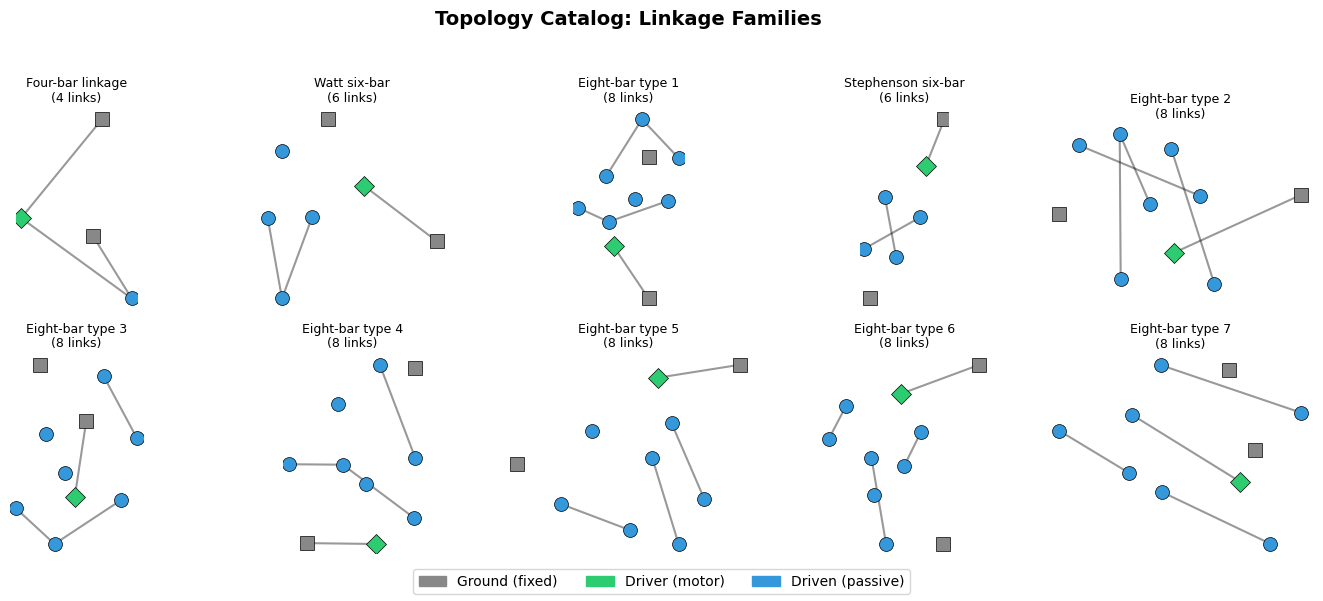

In [3]:
def draw_topology(ax, entry, title=None):
    """Draw a topology graph showing node roles and connections."""
    g = entry.to_graph()
    
    # Layout: simple force-directed approximation
    np.random.seed(hash(entry.id) % 2**31)
    pos = {nid: np.random.randn(2) for nid in g.nodes}
    
    # Spring layout iterations
    for _ in range(100):
        for nid in g.nodes:
            force = np.zeros(2)
            for other_id in g.nodes:
                if other_id == nid:
                    continue
                diff = pos[nid] - pos[other_id]
                dist = max(np.linalg.norm(diff), 0.01)
                force += diff / dist**2 * 0.5  # repulsion
            for neighbor_id in g.all_neighbors(nid):
                diff = pos[neighbor_id] - pos[nid]
                dist = np.linalg.norm(diff)
                force += diff * (dist - 1.0) * 0.1  # spring
            pos[nid] = pos[nid] + force * 0.05
    
    # Draw edges
    for edge in g.edges.values():
        p1, p2 = pos[edge.source], pos[edge.target]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', lw=1.5, alpha=0.4)
    
    # Draw nodes
    colors = {NodeRole.GROUND: '#888888', NodeRole.DRIVER: '#2ecc71', NodeRole.DRIVEN: '#3498db'}
    markers = {NodeRole.GROUND: 's', NodeRole.DRIVER: 'D', NodeRole.DRIVEN: 'o'}
    for nid, node in g.nodes.items():
        c = colors.get(node.role, '#999')
        m = markers.get(node.role, 'o')
        ax.plot(pos[nid][0], pos[nid][1], m, color=c, markersize=10, markeredgecolor='k', markeredgewidth=0.5)
    
    ax.set_title(title or f"{entry.name}\n({entry.num_links} links)", fontsize=9)
    ax.set_aspect('equal')
    ax.axis('off')


fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Topology Catalog: Linkage Families", fontsize=14, fontweight='bold')

# Show one from each family, then fill with eight-bars
show = []
for family, entries in families.items():
    show.append(entries[0])
for entry in list(catalog.entries.values()):
    if entry not in show and len(show) < 10:
        show.append(entry)

for ax, entry in zip(axes.flat, show[:10]):
    draw_topology(ax, entry)

# Legend
legend_elements = [
    mpatches.Patch(color='#888888', label='Ground (fixed)'),
    mpatches.Patch(color='#2ecc71', label='Driver (motor)'),
    mpatches.Patch(color='#3498db', label='Driven (passive)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

## 2. Baseline: A Hand-Designed Walker

Before we let the optimizer search, let's establish a baseline. This is a simple four-bar mechanism — the kind an engineer might sketch as a first attempt. We'll run it through the physics engine and measure how far it walks.

In [4]:
SIM_DURATION = 3.0  # seconds of physics simulation
N_LEGS = 2          # number of legs per walker

def make_baseline_walker():
    """A hand-designed four-bar walking mechanism."""
    hg = HypergraphLinkage(name="baseline_fourbar")
    hg.add_node(Node("G1", role=NodeRole.GROUND))
    hg.add_node(Node("G2", role=NodeRole.GROUND))
    hg.add_node(Node("D", role=NodeRole.DRIVER))
    hg.add_node(Node("P", role=NodeRole.DRIVEN))
    hg.add_edge(Edge("G1_D", "G1", "D"))
    hg.add_edge(Edge("G2_P", "G2", "P"))
    hg.add_edge(Edge("D_P", "D", "P"))

    dims = Dimensions(
        node_positions={"G1": (0, 0), "G2": (2, 0), "D": (1, 0), "P": (1, 2)},
        driver_angles={"D": DriverAngle(angular_velocity=-tau / 12)},
        edge_distances={"G1_D": 1.0, "G2_P": 2.24, "D_P": 2.0},
    )
    return Walker(hg, dims, name="baseline_fourbar", motor_rates=-4.0)


def simulate_walker(walker, duration=SIM_DURATION, record_positions=False):
    """Run physics simulation, return (distance, position_history)."""
    world = World()
    world.add_linkage(walker)
    
    dt = world.config.physics_period
    steps = int(duration / dt)
    positions = [] if record_positions else None
    
    for _ in range(steps):
        world.update()
        if record_positions:
            body = world.linkages[0].body
            positions.append((body.position.x, body.position.y))
    
    distance = float(world.linkages[0].body.position.x)
    return distance, positions


# Build and simulate baseline
baseline = make_baseline_walker()
baseline.add_legs(N_LEGS - 1)
baseline_dist, baseline_pos = simulate_walker(baseline, record_positions=True)

print(f"Baseline four-bar walker: {baseline_dist:.3f}m in {SIM_DURATION}s")
print(f"  Topology: {len(baseline.topology.nodes)} nodes, {len(baseline.topology.edges)} edges")

Baseline four-bar walker: -1.177m in 3.0s
  Topology: 6 nodes, 6 edges


## 3. Discovery: Let the Optimizer Search

Now the key step. We tell the system:
- **Objective**: maximize walking distance (physics-simulated)
- **Search space**: all topologies up to 6 links (four-bars + six-bars)
- **Method**: NSGA-II evolutionary optimization over mixed variables (discrete topology + continuous dimensions)

The optimizer will evolve populations of mechanisms, mutating both their structure and their dimensions, keeping the ones that walk furthest.

In [5]:
# Build the physics-based objective
distance_fitness = DistanceFitness(duration=SIM_DURATION, n_legs=N_LEGS)
objective = co_optimize_objective(distance_fitness, motor_rates=-4.0)

# Show what topologies we're searching over
MAX_LINKS = 6
compatible = catalog.compatible_topologies(max_links=MAX_LINKS)
print(f"Search space: {len(compatible)} topologies (up to {MAX_LINKS} links)")
for e in compatible:
    print(f"  {e.name} ({e.num_links} links, {e.family})")

# Configure the optimizer
co_config = CoOptimizationConfig(
    max_links=MAX_LINKS,
    n_generations=25,
    pop_size=30,
    seed=42,
    verbose=False,
)

print(f"\nRunning {co_config.pop_size} x {co_config.n_generations} = {co_config.pop_size * co_config.n_generations} evaluations...")
t0 = time.time()
result = co_optimize(objectives=[objective], catalog=catalog, config=co_config)
elapsed = time.time() - t0

print(f"Done in {elapsed:.1f}s ({result.n_evaluations} evaluations)")
print(f"Solutions on Pareto front: {len(result.solutions)}")

Search space: 3 topologies (up to 6 links)
  Four-bar linkage (4 links, four-bar)
  Watt six-bar (6 links, six-bar)
  Stephenson six-bar (6 links, six-bar)

Running 30 x 25 = 750 evaluations...


/home/h/Documents/dev/hu/the-great-walker/leggedsnake/.venv/lib/python3.12/site-packages/pymoo/operators/survival/rank_and_crowding/metrics.py:97: RuntimeWarning: invalid value encountered in subtract
  dist = np.vstack([F, np.full(n_obj, np.inf)]) - np.vstack([np.full(n_obj, -np.inf), F])
/home/h/Documents/dev/hu/the-great-walker/leggedsnake/.venv/lib/python3.12/site-packages/pymoo/operators/survival/rank_and_crowding/metrics.py:100: RuntimeWarning: invalid value encountered in subtract
  norm = np.max(F, axis=0) - np.min(F, axis=0)


Done in 4.4s (750 evaluations)
Solutions on Pareto front: 1


## 4. Results: What Did the Optimizer Find?

Let's convert the solutions to Walkers, re-simulate them to get trajectory data, and compare against our baseline.

In [6]:
# Convert solutions to Walkers and simulate
discovered = []
for sol in result.solutions:
    neg_dist = sol.scores[0]
    if neg_dist == float("inf"):
        continue
    
    topo_name = sol.topology_entry.name if sol.topology_entry else "unknown"
    n_links = sol.topology_entry.num_links if sol.topology_entry else 0
    
    try:
        walker = Walker.from_synthesis(sol, motor_rates=-4.0, n_legs=N_LEGS)
        dist, positions = simulate_walker(walker, record_positions=True)
        discovered.append({
            "walker": walker,
            "distance": dist,
            "topology": topo_name,
            "n_links": n_links,
            "positions": positions,
            "co_opt_distance": -neg_dist,
        })
    except Exception as e:
        pass

# Sort by distance
discovered.sort(key=lambda x: x["distance"], reverse=True)

# Print results table
print(f"{'Rank':<6} {'Topology':<25} {'Links':<7} {'Distance':>10}")
print(f"{'─'*6} {'─'*25} {'─'*7} {'─'*10}")
print(f"{'base':<6} {'Hand-designed four-bar':<25} {'4':<7} {baseline_dist:>10.3f}m")
print(f"{'─'*6} {'─'*25} {'─'*7} {'─'*10}")

for i, d in enumerate(discovered[:10]):
    marker = " <-- best" if i == 0 else ""
    print(f"#{i+1:<5} {d['topology']:<25} {d['n_links']:<7} {d['distance']:>10.3f}m{marker}")

if discovered:
    best = discovered[0]
    improvement = ((best["distance"] - baseline_dist) / max(abs(baseline_dist), 0.001)) * 100
    print(f"\nBest discovery: {best['topology']} ({best['n_links']} links)")
    print(f"  Distance: {best['distance']:.3f}m vs baseline {baseline_dist:.3f}m ({improvement:+.1f}%)")

Rank   Topology                  Links     Distance
────── ───────────────────────── ─────── ──────────
base   Hand-designed four-bar    4           -1.177m
────── ───────────────────────── ─────── ──────────


## 5. Visualization: Comparing Trajectories

Let's plot the chassis trajectory (x, y over time) of the baseline and the best discovered mechanism side by side.

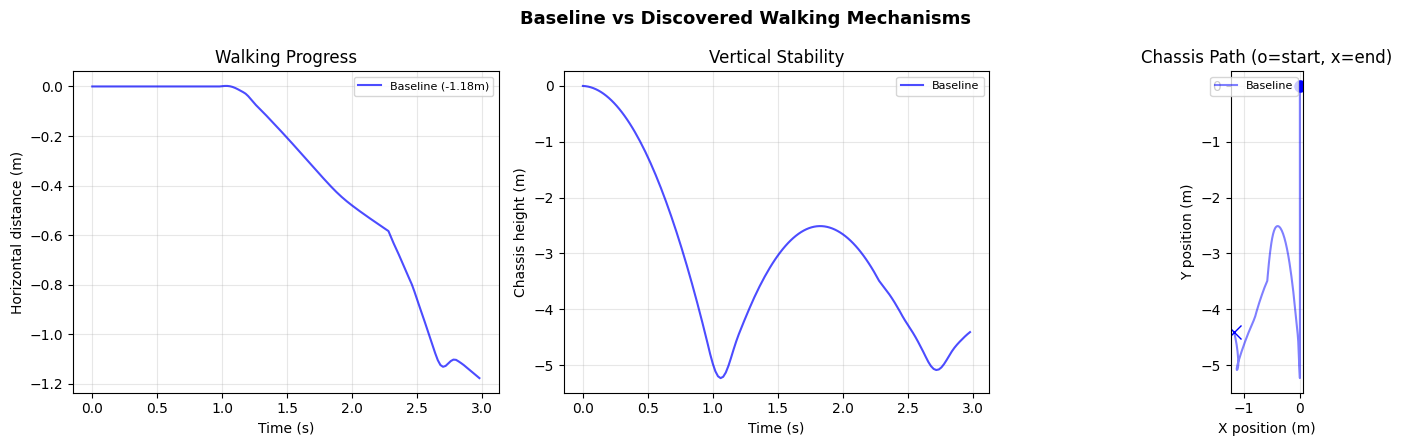

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- Panel 1: Horizontal distance over time ---
ax = axes[0]
dt = 0.02  # physics period
t_baseline = np.arange(len(baseline_pos)) * dt
ax.plot(t_baseline, [p[0] for p in baseline_pos], 'b-', alpha=0.7, label=f"Baseline ({baseline_dist:.2f}m)")

colors = plt.cm.Set1(np.linspace(0, 1, max(len(discovered), 1)))
for i, d in enumerate(discovered[:3]):
    t = np.arange(len(d["positions"])) * dt
    ax.plot(t, [p[0] for p in d["positions"]], '-', color=colors[i], alpha=0.8,
            label=f"{d['topology']} ({d['distance']:.2f}m)")

ax.set_xlabel("Time (s)")
ax.set_ylabel("Horizontal distance (m)")
ax.set_title("Walking Progress")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 2: Chassis height (stability) ---
ax = axes[1]
ax.plot(t_baseline, [p[1] for p in baseline_pos], 'b-', alpha=0.7, label="Baseline")

for i, d in enumerate(discovered[:3]):
    t = np.arange(len(d["positions"])) * dt
    ax.plot(t, [p[1] for p in d["positions"]], '-', color=colors[i], alpha=0.8,
            label=d["topology"])

ax.set_xlabel("Time (s)")
ax.set_ylabel("Chassis height (m)")
ax.set_title("Vertical Stability")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Panel 3: Chassis path (x vs y) ---
ax = axes[2]
ax.plot([p[0] for p in baseline_pos], [p[1] for p in baseline_pos],
        'b-', alpha=0.5, label="Baseline")
ax.plot(baseline_pos[0][0], baseline_pos[0][1], 'bo', markersize=8)
ax.plot(baseline_pos[-1][0], baseline_pos[-1][1], 'bx', markersize=10)

for i, d in enumerate(discovered[:3]):
    pos = d["positions"]
    ax.plot([p[0] for p in pos], [p[1] for p in pos], '-', color=colors[i], alpha=0.5,
            label=d["topology"])
    ax.plot(pos[0][0], pos[0][1], 'o', color=colors[i], markersize=8)
    ax.plot(pos[-1][0], pos[-1][1], 'x', color=colors[i], markersize=10)

ax.set_xlabel("X position (m)")
ax.set_ylabel("Y position (m)")
ax.set_title("Chassis Path (o=start, x=end)")
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

fig.suptitle("Baseline vs Discovered Walking Mechanisms", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Inspecting the Best Mechanism

Let's look at what the optimizer actually discovered — its topology, node roles, and link structure.

In [8]:
if discovered:
    best = discovered[0]
    w = best["walker"]
    topo = w.topology
    dims = w.dimensions
    
    print(f"Best mechanism: {best['topology']}")
    print(f"  Walking distance: {best['distance']:.3f}m")
    print(f"  Nodes: {len(topo.nodes)}")
    print(f"  Edges: {len(topo.edges)}")
    print()
    
    # Show node details
    print("  Node details:")
    for nid, node in topo.nodes.items():
        pos = dims.get_node_position(nid)
        pos_str = f"({pos[0]:.2f}, {pos[1]:.2f})" if pos else "?"
        da = dims.get_driver_angle(nid)
        extra = f"  omega={da.angular_velocity:.3f}" if da else ""
        print(f"    {nid:>20s}  {node.role.name:<8} at {pos_str}{extra}")
    
    print()
    print("  Edge distances:")
    for eid, edge in topo.edges.items():
        dist = dims.get_edge_distance(eid)
        dist_str = f"{dist:.3f}" if dist else "?"
        print(f"    {eid:>20s}: {edge.source} -- {edge.target}  length={dist_str}")

    # Draw the topology graph
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Left: abstract topology
    # Find the catalog entry for this topology
    entry = None
    for e in catalog.entries.values():
        if e.name == best["topology"]:
            entry = e
            break
    if entry:
        draw_topology(ax1, entry, title=f"Topology: {best['topology']}\n({best['n_links']} links)")
    
    # Right: actual mechanism with dimensions
    for eid, edge in topo.edges.items():
        p1 = dims.get_node_position(edge.source)
        p2 = dims.get_node_position(edge.target)
        if p1 and p2:
            ax2.plot([p1[0], p2[0]], [p1[1], p2[1]], 'k-', lw=2, alpha=0.4)
    
    role_colors = {NodeRole.GROUND: '#888888', NodeRole.DRIVER: '#2ecc71', NodeRole.DRIVEN: '#3498db'}
    role_markers = {NodeRole.GROUND: 's', NodeRole.DRIVER: 'D', NodeRole.DRIVEN: 'o'}
    for nid, node in topo.nodes.items():
        pos = dims.get_node_position(nid)
        if pos:
            c = role_colors.get(node.role, '#999')
            m = role_markers.get(node.role, 'o')
            ax2.plot(pos[0], pos[1], m, color=c, markersize=12,
                    markeredgecolor='k', markeredgewidth=1)
            ax2.annotate(nid.split("(")[0].strip(), (pos[0], pos[1]),
                        textcoords="offset points", xytext=(5, 5), fontsize=7)
    
    ax2.set_title(f"Discovered Mechanism\n(distance: {best['distance']:.2f}m)", fontsize=11)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.2)
    
    legend_elements = [
        mpatches.Patch(color='#888888', label='Ground'),
        mpatches.Patch(color='#2ecc71', label='Driver'),
        mpatches.Patch(color='#3498db', label='Driven'),
    ]
    ax2.legend(handles=legend_elements, fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("No valid mechanisms discovered. Try increasing pop_size or n_generations.")

No valid mechanisms discovered. Try increasing pop_size or n_generations.


## 7. What's Happening Under the Hood

The pipeline that produced these results:

```
Topology Catalog (19 linkage families)
        |
        v
co_optimize() — NSGA-II with mixed variables
  - Discrete: which topology (four-bar? Watt six-bar? Stephenson?)
  - Continuous: link lengths, pivot positions
        |
        v  for each candidate chromosome:
co_optimize_objective() adapter
  1. Build Linkage from chromosome
  2. walker_from_legacy() -> Walker
  3. DynamicFitness: run pymunk physics for N seconds
  4. Return -distance (minimized)
        |
        v
Pareto front of (topology, dimensions) solutions
        |
        v
Walker.from_synthesis() -> ranked Walker objects
```

**This is the core value**: specify *what you want* (walking distance, efficiency, obstacle clearance), and the system searches *across mechanism families* to find both the structure and the dimensions. No need to know that a Strider uses 11 joints or that a Klann has a rigid triangle — the optimizer discovers the right topology for your constraints.

## Next Steps

To improve results:
- Increase `n_generations` and `pop_size` for deeper search
- Add a kinematic pre-filter (`StrideFitness`) to reject bad foot paths cheaply
- Use multi-objective optimization (distance + efficiency) for Pareto trade-offs
- Try `max_links=8` to include 16 eight-bar topologies in the search
- Use `WalkingDesignSpec` + `optimize_walking_mechanism()` for the full pipeline with terrain configuration

## 8. Co-evolving gait with topology + dimensions (Phase 8.3)

Sections 3–7 above search topology + dimensions but apply the *classical
evenly-spaced rotating-stack* gait: ``Walker.add_legs(n)`` places the
k-th leg at phase ``tau * k / (n + 1)``. That works for symmetric
mechanisms but leaves trot, pace, canter, and asymmetric gaits
unreachable.

Phase 8.3 folds the per-leg phase offsets into the same NSGA-II/III
chromosome managed by leggedsnake's ``topology_walking_optimization``:

```
[topology_idx, [n_legs,] dim_1, ..., dim_max, off_1, ..., off_M]
                                              ^^^ new in 8.3 ^^^
```

with ``M = max(leg_bounds) - 1`` continuous genes bounded ``[0, tau)``.
Set ``evolve_offsets=True`` and gait pattern co-evolves with structure
and geometry — each Pareto solution's ``TopologySolutionInfo`` carries
the evolved ``phase_offsets`` directly.

In [9]:
from leggedsnake.topology_optimization import (
    TopologyCoOptConfig, topology_walking_optimization,
)
from leggedsnake import DistanceFitness

cfg = TopologyCoOptConfig(
    max_links=4,
    n_generations=4,
    pop_size=8,
    seed=0,
    verbose=False,
    n_legs=4,             # 4 legs => 3 phase-offset genes
    evolve_offsets=True,  # the Phase 8.3 switch
)
result = topology_walking_optimization(
    objectives=[DistanceFitness(duration=2.0, n_legs=1)],
    objective_names=["distance"],
    config=cfg,
)

print(f"Pareto solutions: {len(result.pareto_front.solutions)}")
for i, info in result.topology_info.items():
    offs = info.phase_offsets
    fmt = "[" + ", ".join(f"{o:.2f}" for o in offs) + "]" if offs else "None"
    print(f"  [{i}] {info.topology_name:<22} n_legs={info.n_legs}  offsets={fmt}")

Pareto solutions: 1
  [0] Four-bar linkage       n_legs=4  offsets=[0.72, 4.66, 3.30]


The evolved offsets land somewhere in ``[0, tau)`` — not necessarily at
the evenly-spaced ``tau * k / n_legs`` grid points the classical gait
prescribes. Plotting them side by side makes the deviation visible:

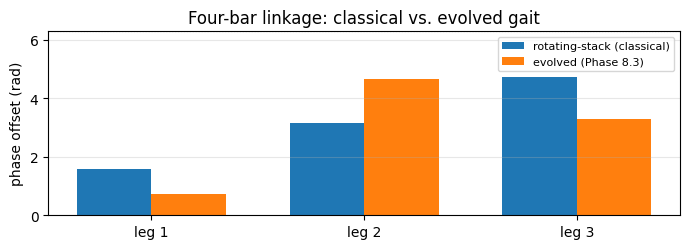

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from math import tau

if result.topology_info:
    info = result.topology_info[0]
    evolved = info.phase_offsets or []
    n = info.n_legs
    # Walker.add_legs(n - 1) uses tau * k / n for k=1..n-1
    even = [tau * k / n for k in range(1, n)]

    fig, ax = plt.subplots(figsize=(7, 2.6))
    width = 0.35
    x = np.arange(len(evolved))
    ax.bar(x - width / 2, even, width, label="rotating-stack (classical)")
    ax.bar(x + width / 2, evolved, width, label="evolved (Phase 8.3)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"leg {i + 1}" for i in range(len(evolved))])
    ax.set_ylabel("phase offset (rad)")
    ax.set_title(f"{info.topology_name}: classical vs. evolved gait")
    ax.set_ylim(0, tau)
    ax.axhline(tau, color="grey", linestyle=":", linewidth=0.8)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No Pareto solutions to plot — try a larger pop_size / n_generations.")

**When to use this.** ``evolve_offsets=True`` adds ``n_legs - 1``
continuous genes per chromosome — for ``n_legs=4`` that's 3 extra
dimensions on top of the topology + dimensions search. Use it when
the *gait pattern* matters (asymmetric terrain, payload offsets,
multi-DOF drivers) and skip it when symmetric rotating-stack walking
is fine for the application.

For pure phase-offset tuning of a *fixed* mechanism, the standalone
``optimize_gait`` (``leggedsnake.gait_optimization``) is faster — it
runs scipy's differential evolution on just the offset axis. Phase
8.3 is the upgrade for the joint search; use whichever matches the
question.